# ML Practical Assignment — Loan Prediction Dataset
**Dataset:** `https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv`

This notebook follows the assignment's required flow: **Understand → Calculate → Code → Verify → Interpret**. The main preprocessing and feature-selection logic is implemented from scratch using Python/Pandas/NumPy, and library functions are used only for verification where appropriate.

> **Leakage rule:** supervised feature selection and learned preprocessing parameters are fitted using the training split only, then applied to the test split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from IPython.display import display

URL = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"
df = pd.read_csv(URL)
pd.set_option("display.max_columns", None)
print("Dataset loaded:", df.shape)
display(df.head())

Dataset loaded: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Part A — Problem and Dataset Understanding
The dataset represents a **loan eligibility/approval classification** problem. A housing-finance company wants to automate the decision of whether an applicant is eligible for a loan based on demographic, financial and credit-related information.

**Target:** `Loan_Status` (`Y` = approved, `N` = not approved).

The source repository describes the fields as Loan_ID, Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area and Loan_Status. citeturn0search1

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:", list(df.columns))
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nUnique values:")
display(df.nunique(dropna=False).to_frame("unique_values"))
print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))
print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Rows: 614
Columns: 13

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data types:


,dtype
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



Unique values:


,unique_values
Loan_ID,614
Gender,3
Married,3
Dependents,5
Education,2
Self_Employed,3
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,204
Loan_Amount_Term,11



Missing values:


,missing_values
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP002990,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


### Feature dictionary

In [3]:
feature_table = pd.DataFrame({
    "Feature": ["Loan_ID","Gender","Married","Dependents","Education","Self_Employed",
                "ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term",
                "Credit_History","Property_Area","Loan_Status"],
    "Description": ["Unique loan identifier","Applicant gender","Marital status","Number of dependents",
                    "Applicant education","Whether self-employed","Applicant income",
                    "Coapplicant income","Loan amount (thousands)","Loan term (months)",
                    "Whether credit history meets guidelines","Property area","Loan approved"],
    "Data Type": ["Identifier","Categorical","Categorical","Categorical","Categorical","Categorical",
                  "Numerical","Numerical","Numerical","Numerical","Binary numerical","Categorical","Categorical"],
    "Role": ["Identifier","Input","Input","Input","Input","Input","Input","Input","Input","Input","Input","Input","Target"]
})
display(feature_table)

,Feature,Description,Data Type,Role
0,Loan_ID,Unique loan identifier,Identifier,Identifier
1,Gender,Applicant gender,Categorical,Input
2,Married,Marital status,Categorical,Input
3,Dependents,Number of dependents,Categorical,Input
4,Education,Applicant education,Categorical,Input
5,Self_Employed,Whether self-employed,Categorical,Input
6,ApplicantIncome,Applicant income,Numerical,Input
7,CoapplicantIncome,Coapplicant income,Numerical,Input
8,LoanAmount,Loan amount (thousands),Numerical,Input
9,Loan_Amount_Term,Loan term (months),Numerical,Input


## Part B — Initial Exploration and Basic Statistics

In [4]:
print("First 5 records")
display(df.head())
print("Last 5 records")
display(df.tail())
print("Shape:", df.shape)

num_cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]
for col in num_cols:
    x = df[col].dropna().to_numpy()
    n = len(x)
    mean = sum(x)/n
    med = np.median(x)
    vals, counts = np.unique(x, return_counts=True)
    mode = vals[np.argmax(counts)]
    var = sum((v-mean)**2 for v in x)/n
    sd = var**0.5
    print(f"\n{col}")
    print("min =", x.min(), "max =", x.max(), "mean =", mean, "median =", med,
          "mode =", mode, "variance =", var, "std =", sd, "range =", x.max()-x.min())

print("\nVerification with pandas:")
display(df[num_cols].agg(["min","max","mean","median","var","std"]))

First 5 records


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Last 5 records


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


Shape: (614, 13)

ApplicantIncome
min = 150 max = 81000 mean = 5403.459283387622 median = 3812.5 mode = 2500 variance = 37259607.772772074 std = 6104.064856533888 range = 80850

CoapplicantIncome
min = 0.0 max = 41667.0 mean = 1621.245798027101 median = 1188.5 mode = 0.0 variance = 8548983.37910648 std = 2923.8644597700627 range = 41667.0

LoanAmount
min = 9.0 max = 700.0 mean = 146.41216216216216 median = 128.0 mode = 120.0 variance = 7312.816608838569 std = 85.51500809120331 range = 691.0

Loan_Amount_Term
min = 12.0 max = 480.0 mean = 342.0 median = 360.0 mode = 360.0 variance = 4233.6 std = 65.0661202162846 range = 468.0

Credit_History
min = 0.0 max = 1.0 mean = 0.8421985815602837 median = 1.0 mode = 1.0 variance = 0.13290013077812995 std = 0.3645547020381577 range = 1.0

Verification with pandas:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
min,1.500000e+02,0.000000e+00,9.000000,12.00000,0.000000
max,8.100000e+04,4.166700e+04,700.000000,480.00000,1.000000
mean,5.403459e+03,1.621246e+03,146.412162,342.00000,0.842199
median,3.812500e+03,1.188500e+03,128.000000,360.00000,1.000000
var,3.732039e+07,8.562930e+06,7325.190241,4240.66778,0.133136
std,6.109042e+03,2.926248e+03,85.587325,65.12041,0.364878


## Part C — Missing Values
Missing percentage = `(missing values / total observations) × 100`.

The primary implementation below uses **training-set parameters only**. Numeric variables use the training median (robust to extreme values), while categorical variables use the training mode.

In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": df.isna().mean()*100
})
display(missing.sort_values("Missing Values", ascending=False))

,Missing Values,Missing %
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Education,0,0.000000
Loan_ID,0,0.000000
CoapplicantIncome,0,0.000000


## Part D — Duplicates and Invalid Data

In [6]:
print("Original records:", len(df))
print("Duplicate rows:", df.duplicated().sum())
clean = df.drop_duplicates().copy()
print("Records after duplicate treatment:", len(clean))

# Basic validity checks
print("\nNegative numerical values:")
for c in ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]:
    print(c, int((clean[c].dropna() < 0).sum()))

print("\nUnexpected categories:")
for c in ["Gender","Married","Dependents","Education","Self_Employed","Credit_History","Property_Area","Loan_Status"]:
    print(c, sorted(clean[c].dropna().astype(str).unique().tolist()))

Original records: 614
Duplicate rows: 0
Records after duplicate treatment: 614

Negative numerical values:
ApplicantIncome 0
CoapplicantIncome 0
LoanAmount 0
Loan_Amount_Term 0

Unexpected categories:
Gender ['Female', 'Male']
Married ['No', 'Yes']
Dependents ['0', '1', '2', '3+']
Education ['Graduate', 'Not Graduate']
Self_Employed ['No', 'Yes']
Credit_History ['0.0', '1.0']
Property_Area ['Rural', 'Semiurban', 'Urban']
Loan_Status ['N', 'Y']


No negative income/loan values are expected here. Category consistency is checked before encoding. `Loan_ID` is an identifier rather than a predictive feature and is therefore removed from the modeling matrix.

## Part J + K — Train/Test Split and Data Leakage
An 80/20 split is created **before fitting learned preprocessing parameters**. The split is implemented manually with a seeded permutation instead of using `train_test_split` for the primary split.

In [7]:
# Manual 80/20 split
rng = np.random.default_rng(42)
idx = np.arange(len(clean))
rng.shuffle(idx)
cut = int(0.80 * len(idx))
train_idx, test_idx = idx[:cut], idx[cut:]

train = clean.iloc[train_idx].reset_index(drop=True).copy()
test = clean.iloc[test_idx].reset_index(drop=True).copy()

print("Train:", train.shape, "Test:", test.shape)
print("Train target distribution:")
display(train["Loan_Status"].value_counts(normalize=True))
print("Test target distribution:")
display(test["Loan_Status"].value_counts(normalize=True))

# Verification only
Xv = clean.drop(columns=["Loan_Status"])
yv = clean["Loan_Status"]
Xa, Xb, ya, yb = train_test_split(Xv, yv, test_size=0.20, random_state=42)
print("\nLibrary verification split sizes:", Xa.shape[0], Xb.shape[0])

Train: (491, 13) Test: (123, 13)
Train target distribution:


,proportion
Loan_Status,
Y,0.668024
N,0.331976


Test target distribution:


,proportion
Loan_Status,
Y,0.764228
N,0.235772



Library verification split sizes: 491 123


### Leakage-safe preprocessing functions (from scratch)

In [8]:
target = "Loan_Status"
id_col = "Loan_ID"

categorical = ["Gender","Married","Dependents","Education","Self_Employed","Property_Area"]
numeric = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]

def fit_imputation(train_df):
    params = {}
    for c in numeric:
        params[c] = train_df[c].median()
    for c in categorical:
        params[c] = train_df[c].mode(dropna=True).iloc[0]
    return params

def apply_imputation(df_in, params):
    out = df_in.copy()
    for c, value in params.items():
        out[c] = out[c].fillna(value)
    return out

imp_params = fit_imputation(train)
train_imp = apply_imputation(train, imp_params)
test_imp = apply_imputation(test, imp_params)

print("Missing values after treatment (train):", int(train_imp.isna().sum().sum()))
print("Missing values after treatment (test):", int(test_imp.isna().sum().sum()))
print("Training imputation parameters:")
print(imp_params)

Missing values after treatment (train): 0
Missing values after treatment (test): 0
Training imputation parameters:
{'ApplicantIncome': 3812.0, 'CoapplicantIncome': 1083.0, 'LoanAmount': 127.5, 'Loan_Amount_Term': 360.0, 'Credit_History': 1.0, 'Gender': 'Male', 'Married': 'Yes', 'Dependents': '0', 'Education': 'Graduate', 'Self_Employed': 'No', 'Property_Area': 'Semiurban'}


## Part E — Categorical Encoding
**Label encoding** is demonstrated for an ordinal/binary variable (`Education`). For nominal categories such as `Property_Area`, **one-hot encoding** is preferable because assigning arbitrary integers can imply a false order.

In [9]:
# Label encoding from scratch
education_mapping = {"Graduate": 0, "Not Graduate": 1}
label_demo = train_imp["Education"].map(education_mapping)
print("Education mapping:", education_mapping)
display(pd.DataFrame({"Education": train_imp["Education"].head(10), "Encoded": label_demo.head(10)}))

# One-hot encoding from scratch
def fit_one_hot_categories(train_df, cols):
    return {c: sorted(train_df[c].astype(str).unique().tolist()) for c in cols}

def one_hot_from_scratch(df_in, categories):
    out = pd.DataFrame(index=df_in.index)
    for c, levels in categories.items():
        for level in levels:
            out[f"{c}_{level}"] = (df_in[c].astype(str) == level).astype(int)
    return out

onehot_levels = fit_one_hot_categories(train_imp, categorical)
train_ohe = one_hot_from_scratch(train_imp, onehot_levels)
test_ohe = one_hot_from_scratch(test_imp, onehot_levels)

print("One-hot shape:", train_ohe.shape)
display(train_ohe.head())

Education mapping: {'Graduate': 0, 'Not Graduate': 1}


,Education,Encoded
0,Not Graduate,1
1,Not Graduate,1
2,Graduate,0
3,Graduate,0
4,Graduate,0
5,Not Graduate,1
6,Not Graduate,1
7,Graduate,0
8,Not Graduate,1
9,Graduate,0


One-hot shape: (491, 15)


,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,1,0,1,0,0,1,0,0,1,1,0,0,1,0
1,0,1,0,1,0,0,1,0,0,1,1,0,0,0,1
2,0,1,0,1,0,1,0,0,1,0,1,0,0,0,1
3,0,1,0,1,0,0,1,0,1,0,0,1,1,0,0
4,0,1,0,1,0,1,0,0,1,0,1,0,0,1,0


## Part F — Outliers: IQR and Z-score
IQR bounds are `Q1 - 1.5×IQR` and `Q3 + 1.5×IQR`. Z-score uses `z=(x-μ)/σ` and flags `|z|>3`.

Outliers are not automatically deleted. In this dataset, extreme income/loan observations can be legitimate applicants, so the main treatment below is **capping** at training-set IQR bounds rather than deleting rows.

In [10]:
outlier_report = []
iqr_bounds = {}
for c in ["ApplicantIncome","CoapplicantIncome","LoanAmount"]:
    x = train_imp[c].to_numpy(dtype=float)
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    z = np.abs((x-x.mean())/x.std(ddof=0))
    iqr_n = int(((x<lo)|(x>hi)).sum())
    z_n = int((z>3).sum())
    iqr_bounds[c] = (lo, hi)
    outlier_report.append([c,q1,q3,iqr,lo,hi,iqr_n,z_n])
outlier_report = pd.DataFrame(outlier_report, columns=["Feature","Q1","Q3","IQR","Lower","Upper","IQR Outliers","Z>3 Outliers"])
display(outlier_report)

def cap_with_train_bounds(df_in, bounds):
    out = df_in.copy()
    for c,(lo,hi) in bounds.items():
        out[c] = out[c].clip(lo,hi)
    return out

train_cap = cap_with_train_bounds(train_imp, iqr_bounds)
test_cap = cap_with_train_bounds(test_imp, iqr_bounds)

,Feature,Q1,Q3,IQR,Lower,Upper,IQR Outliers,Z>3 Outliers
0,ApplicantIncome,2941.0,5825.0,2884.0,-1385.00,10151.00,37,7
1,CoapplicantIncome,0.0,2331.5,2331.5,-3497.25,5828.75,14,4
2,LoanAmount,102.0,161.0,59.0,13.50,249.50,42,9


## Part G — Transformation
Income and loan amount are often right-skewed. We inspect skewness and apply `log1p(x)` to strongly right-skewed non-negative variables. The decision is learned from training data only.

Training skewness before:


,skew_before
ApplicantIncome,1.040463
CoapplicantIncome,1.008024
LoanAmount,0.597484


Log-transformed columns: ['ApplicantIncome', 'CoapplicantIncome']


,skew_after
ApplicantIncome_log,-0.708585
CoapplicantIncome_log,-0.145627


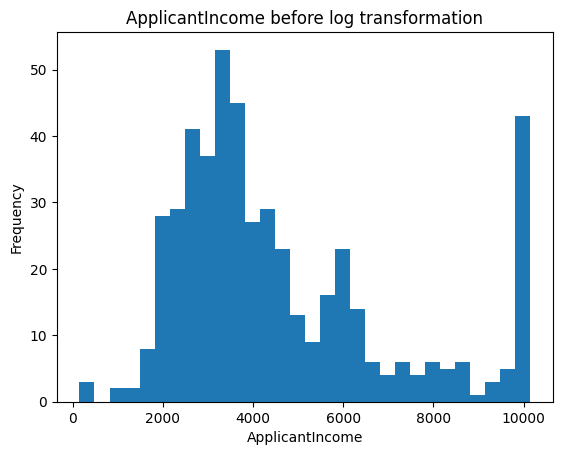

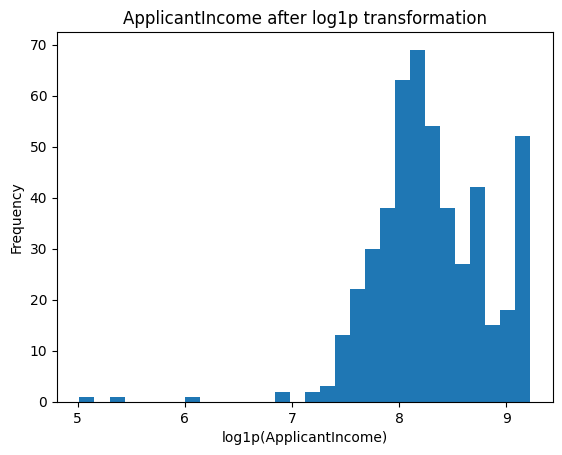

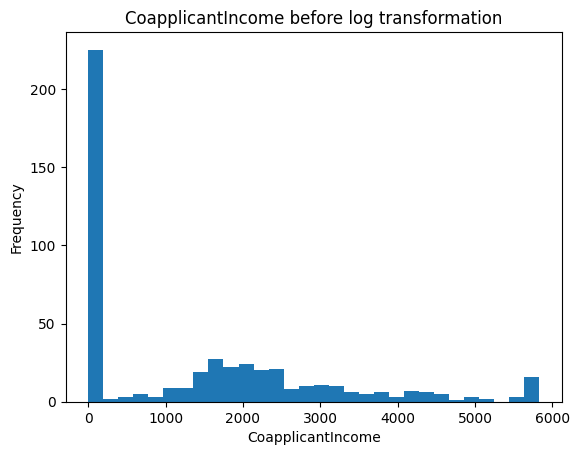

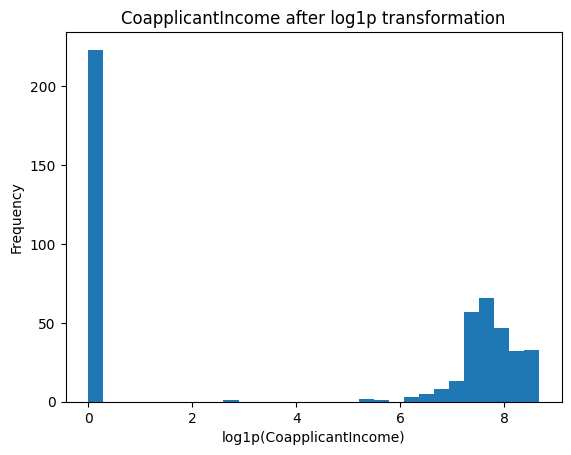

In [11]:
transform_cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount"]
skew_before = train_cap[transform_cols].skew()
print("Training skewness before:")
display(skew_before.to_frame("skew_before"))

selected_log = [c for c in transform_cols if skew_before[c] > 1]
for c in selected_log:
    train_cap[c+"_log"] = np.log1p(train_cap[c])
    test_cap[c+"_log"] = np.log1p(test_cap[c])

skew_after = train_cap[[c+"_log" for c in selected_log]].skew()
print("Log-transformed columns:", selected_log)
display(skew_after.to_frame("skew_after"))

for c in selected_log:
    fig, ax = plt.subplots()
    ax.hist(train_cap[c], bins=30)
    ax.set_title(f"{c} before log transformation")
    ax.set_xlabel(c); ax.set_ylabel("Frequency")
    plt.show()
    fig, ax = plt.subplots()
    ax.hist(train_cap[c+"_log"], bins=30)
    ax.set_title(f"{c} after log1p transformation")
    ax.set_xlabel("log1p("+c+")"); ax.set_ylabel("Frequency")
    plt.show()

## Part H — Feature Scaling
### Min-Max normalization
`x' = (x - min) / (max - min)`

### Standardization
`z = (x - μ) / σ`

Both sets of parameters are learned from training data only.

In [12]:
scale_cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"] + [c+"_log" for c in selected_log]

train_num = train_cap[scale_cols].copy()
test_num = test_cap[scale_cols].copy()

mins = train_num.min()
maxs = train_num.max()
means = train_num.mean()
stds = train_num.std(ddof=0)

train_minmax = (train_num - mins) / (maxs-mins).replace(0,1)
test_minmax = (test_num - mins) / (maxs-mins).replace(0,1)
train_std = (train_num - means) / stds.replace(0,1)
test_std = (test_num - means) / stds.replace(0,1)

display(pd.DataFrame({
    "Original": train_num.iloc[0],
    "Min-Max": train_minmax.iloc[0],
    "Standardized": train_std.iloc[0]
}))

print("Min-max ranges:")
display(pd.DataFrame({"min":train_minmax.min(), "max":train_minmax.max()}))

# Library verification
mm = MinMaxScaler().fit(train_num)
ss = StandardScaler().fit(train_num)
print("Max absolute MinMax difference:",
      np.max(np.abs(train_minmax.to_numpy()-mm.transform(train_num))))
print("Max absolute Standardization difference:",
      np.max(np.abs(train_std.to_numpy()-ss.transform(train_num))))

,Original,Min-Max,Standardized
ApplicantIncome,3333.000000,0.318268,-0.528782
CoapplicantIncome,2000.000000,0.343127,0.365633
LoanAmount,99.000000,0.362288,-0.701280
Loan_Amount_Term,360.000000,0.743590,0.285566
Credit_History,1.000000,1.000000,0.431266
ApplicantIncome_log,8.111928,0.735395,-0.356851
CoapplicantIncome_log,7.601402,0.876674,0.880060


Min-max ranges:


,min,max
ApplicantIncome,0.0,1.0
CoapplicantIncome,0.0,1.0
LoanAmount,0.0,1.0
Loan_Amount_Term,0.0,1.0
Credit_History,0.0,1.0
ApplicantIncome_log,0.0,1.0
CoapplicantIncome_log,0.0,1.0


Max absolute MinMax difference: 3.3306690738754696e-16
Max absolute Standardization difference: 1.687538997430238e-14


## Part I — Visualizations

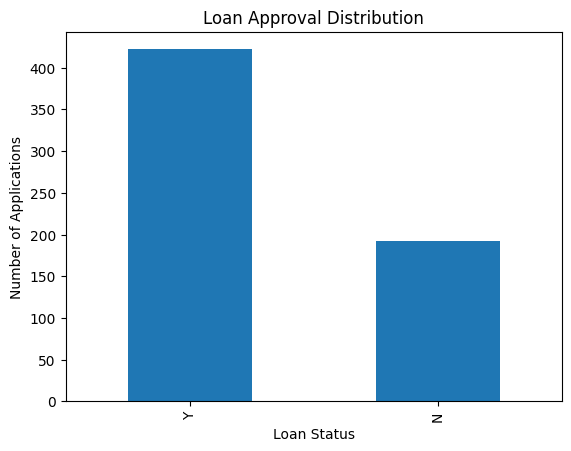

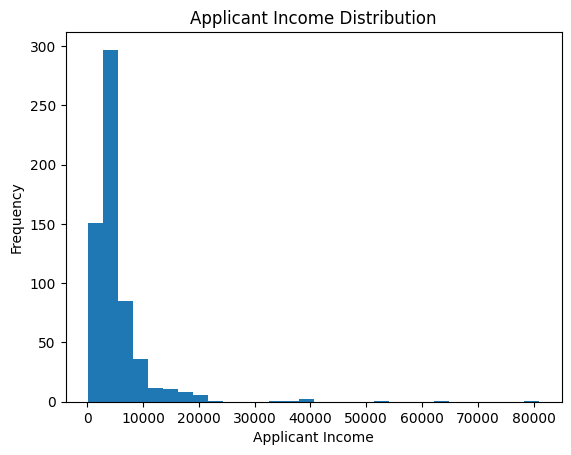

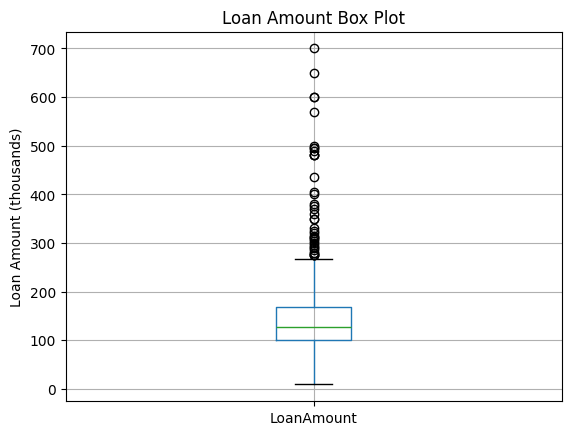

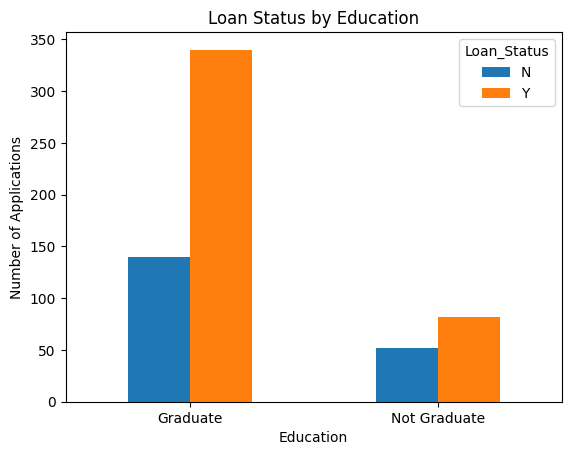

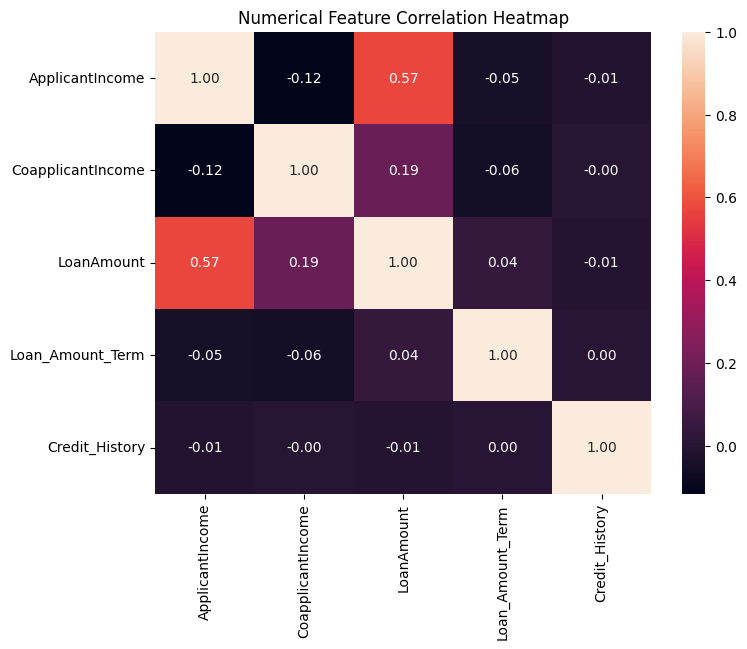

In [13]:
# Target bar chart
fig, ax = plt.subplots()
df["Loan_Status"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Loan Approval Distribution")
ax.set_xlabel("Loan Status"); ax.set_ylabel("Number of Applications")
plt.show()

# Income histogram
fig, ax = plt.subplots()
df["ApplicantIncome"].dropna().plot(kind="hist", bins=30, ax=ax)
ax.set_title("Applicant Income Distribution")
ax.set_xlabel("Applicant Income"); ax.set_ylabel("Frequency")
plt.show()

# Loan amount box plot
fig, ax = plt.subplots()
df.boxplot(column="LoanAmount", ax=ax)
ax.set_title("Loan Amount Box Plot")
ax.set_ylabel("Loan Amount (thousands)")
plt.show()

# Education vs loan status
ct = pd.crosstab(df["Education"], df["Loan_Status"])
ct.plot(kind="bar")
plt.title("Loan Status by Education")
plt.xlabel("Education"); plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.show()

# Correlation heatmap
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, ax=ax, fmt=".2f")
ax.set_title("Numerical Feature Correlation Heatmap")
plt.show()

## Part M — Feature Selection
We use the technique appropriate to each data type:

* **Variance:** detect zero/low-variance numerical variables.
* **Pearson correlation:** numerical–numerical relationships and numerical relationship with binary target.
* **Chi-square:** categorical/discrete feature vs categorical target.
* **ANOVA F-test:** numerical feature vs categorical target.
* **Mutual information:** discrete/categorical feature vs categorical target, with a from-scratch example.

Supervised scores are computed on the **training data only**.

In [14]:
# Prepare training data for feature-selection analysis
fs = train_imp.copy()
fs["Loan_Status_num"] = fs["Loan_Status"].map({"N":0,"Y":1})

# M1 Variance
variance_rows=[]
for c in numeric:
    v = np.var(fs[c].to_numpy(dtype=float), ddof=0)
    variance_rows.append([c,v,"Keep" if v>1e-12 else "Remove"])
variance_df=pd.DataFrame(variance_rows,columns=["Feature","Variance","Decision"])
display(variance_df.sort_values("Variance"))

# M2 Pearson from scratch
def pearson_manual(x,y):
    x=np.asarray(x,dtype=float); y=np.asarray(y,dtype=float)
    xm=x.mean(); ym=y.mean()
    num=np.sum((x-xm)*(y-ym))
    den=np.sqrt(np.sum((x-xm)**2)*np.sum((y-ym)**2))
    return num/den if den else 0.0

pearson_rows=[]
for c in numeric:
    r=pearson_manual(fs[c], fs["Loan_Status_num"])
    pearson_rows.append([c,r,abs(r)])
pearson_df=pd.DataFrame(pearson_rows,columns=["Feature","Pearson r","|r|"]).sort_values("|r|",ascending=False)
display(pearson_df)

# Verify
print("Pandas correlation verification:")
display(fs[numeric+["Loan_Status_num"]].corr()["Loan_Status_num"].drop("Loan_Status_num"))

,Feature,Variance,Decision
4,Credit_History,1.322294e-01,Keep
3,Loan_Amount_Term,4.388007e+03,Keep
2,LoanAmount,5.955605e+03,Keep
1,CoapplicantIncome,9.720683e+06,Keep
0,ApplicantIncome,3.578802e+07,Keep


,Feature,Pearson r,|r|
4,Credit_History,0.552303,0.552303
1,CoapplicantIncome,-0.053080,0.053080
2,LoanAmount,-0.017740,0.017740
0,ApplicantIncome,-0.017480,0.017480
3,Loan_Amount_Term,-0.003877,0.003877


Pandas correlation verification:


,Loan_Status_num
ApplicantIncome,-0.017480
CoapplicantIncome,-0.053080
LoanAmount,-0.017740
Loan_Amount_Term,-0.003877
Credit_History,0.552303


In [15]:
# M3 Chi-square from scratch
def chi_square_manual(feature, target):
    table = pd.crosstab(feature, target)
    observed = table.to_numpy(dtype=float)
    row_tot = observed.sum(axis=1, keepdims=True)
    col_tot = observed.sum(axis=0, keepdims=True)
    grand = observed.sum()
    expected = row_tot @ col_tot / grand
    contrib = (observed-expected)**2 / expected
    chi = contrib.sum()
    dfree=(observed.shape[0]-1)*(observed.shape[1]-1)
    return table, pd.DataFrame(expected,index=table.index,columns=table.columns), pd.DataFrame(contrib,index=table.index,columns=table.columns), chi, dfree

chi_rows=[]
for c in categorical:
    table, expected, contrib, chi, dfree = chi_square_manual(fs[c], fs["Loan_Status"])
    chi_rows.append([c,chi,dfree])
    print(f"\n{c} contingency table:")
    display(table)
    print("Expected:")
    display(expected.round(3))
    print("Contribution:")
    display(contrib.round(3))
chi_df=pd.DataFrame(chi_rows,columns=["Feature","Chi-Square","df"]).sort_values("Chi-Square",ascending=False)
display(chi_df)

# Verification
X_cat = pd.get_dummies(fs[categorical], drop_first=False)
y_cat = fs["Loan_Status_num"]
chi_lib, p_lib = chi2(X_cat, y_cat)
print("Library chi-square verification (one-hot columns):")
display(pd.DataFrame({"encoded_feature":X_cat.columns,"chi2":chi_lib,"p_value":p_lib}).sort_values("chi2",ascending=False).head(15))


Gender contingency table:


Loan_Status,N,Y
Gender,,
Female,30,62
Male,133,266


Expected:


Loan_Status,N,Y
Gender,,
Female,30.542,61.458
Male,132.458,266.542


Contribution:


...

Contribution:


Loan_Status,N,Y
Property_Area,,
Rural,1.874,0.932
Semiurban,5.187,2.578
Urban,1.256,0.624


,Feature,Chi-Square,df
5,Property_Area,12.451311,2
3,Education,5.510677,1
1,Married,4.015733,1
2,Dependents,1.377449,3
4,Self_Employed,0.972199,1
0,Gender,0.017702,1


Library chi-square verification (one-hot columns):


,encoded_feature,chi2,p_value
13,Property_Area_Semiurban,7.764650,0.005328
9,Education_Not Graduate,4.298553,0.038145
12,Property_Area_Rural,2.805934,0.093916
2,Married_No,2.658072,0.103026
14,Property_Area_Urban,1.880727,0.170251
3,Married_Yes,1.357661,0.243943
8,Education_Graduate,1.212124,0.270912
11,Self_Employed_Yes,0.849436,0.356712
6,Dependents_2,0.842404,0.358710
5,Dependents_1,0.336114,0.562081


In [16]:
# M4 ANOVA F-test from scratch
def anova_manual(values, groups):
    temp=pd.DataFrame({"x":values,"g":groups})
    overall=temp["x"].mean()
    grouped=temp.groupby("g")["x"]
    counts=grouped.count(); means=grouped.mean()
    ss_between=sum(counts[g]*(means[g]-overall)**2 for g in means.index)
    ss_within=sum(((grp-means[g])**2).sum() for g,grp in temp.groupby("g")["x"])
    k=len(means); n=len(temp)
    df_between=k-1; df_within=n-k
    ms_between=ss_between/df_between
    ms_within=ss_within/df_within
    F=ms_between/ms_within if ms_within else np.inf
    return overall,means,ss_between,ss_within,df_between,df_within,F

anova_rows=[]
for c in ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]:
    overall,means,ssb,ssw,dfb,dfw,F=anova_manual(fs[c],fs["Loan_Status"])
    anova_rows.append([c,F,dfb,dfw])
anova_df=pd.DataFrame(anova_rows,columns=["Feature","F-statistic","df_between","df_within"]).sort_values("F-statistic",ascending=False)
display(anova_df)

F_lib,p_lib=f_classif(fs[["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]],fs["Loan_Status_num"])
display(pd.DataFrame({"Feature":["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"],"F_library":F_lib,"p_library":p_lib}))

,Feature,F-statistic,df_between,df_within
1,CoapplicantIncome,1.381648,1,489
2,LoanAmount,0.153934,1,489
0,ApplicantIncome,0.149461,1,489
3,Loan_Amount_Term,0.007352,1,489


,Feature,F_library,p_library
0,ApplicantIncome,0.149461,0.699219
1,CoapplicantIncome,1.381648,0.240393
2,LoanAmount,0.153934,0.694975
3,Loan_Amount_Term,0.007352,0.931706


In [17]:
# M5 Mutual Information from scratch for a suitable discrete feature
def entropy_bits(values):
    s=pd.Series(values)
    probs=s.value_counts(normalize=True).to_numpy()
    return float(-np.sum(probs*np.log2(probs)))

def mutual_information_discrete(x,y):
    x=pd.Series(x); y=pd.Series(y)
    n=len(x)
    joint=pd.crosstab(x,y,normalize=True)
    px=x.value_counts(normalize=True); py=y.value_counts(normalize=True)
    mi=0.0
    for xv in joint.index:
        for yv in joint.columns:
            pxy=joint.loc[xv,yv]
            if pxy>0:
                mi += pxy*np.log2(pxy/(px[xv]*py[yv]))
    return float(mi)

mi_rows=[]
for c in categorical:
    mi_rows.append([c, entropy_bits(fs["Loan_Status"]), mutual_information_discrete(fs[c],fs["Loan_Status"])])
mi_df=pd.DataFrame(mi_rows,columns=["Feature","H(Y) bits","MI bits"]).sort_values("MI bits",ascending=False)
display(mi_df)

demo_feature="Credit_History"
print("From-scratch MI demonstration for",demo_feature)
print("H(Y) =",entropy_bits(fs["Loan_Status"]))
print("MI(X;Y) =",mutual_information_discrete(fs[demo_feature],fs["Loan_Status"]), "bits")

,Feature,H(Y) bits,MI bits
5,Property_Area,0.916932,0.018815
3,Education,0.916932,0.007877
1,Married,0.916932,0.005829
2,Dependents,0.916932,0.002046
4,Self_Employed,0.916932,0.001398
0,Gender,0.916932,0.000026


From-scratch MI demonstration for Credit_History
H(Y) = 0.9169320724523773
MI(X;Y) = 0.22189841331647997 bits


### Final feature-selection decision
A statistical score is evidence, not an automatic deletion rule. We retain features with useful information while removing the identifier `Loan_ID`. For the final model matrix, nominal categorical variables are one-hot encoded and the target is excluded from the feature set.

A practical decision table is generated below so the exact scores from the current run are visible.

In [18]:
# Build a transparent decision table
decision = []
for c in ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]:
    score = float(pearson_df.loc[pearson_df["Feature"]==c,"|r|"].iloc[0])
    decision.append([c,"Numerical","Pearson / ANOVA",score,"Keep","No zero variance; useful numerical signal considered jointly with other evidence."])
for c in categorical:
    score=float(mi_df.loc[mi_df["Feature"]==c,"MI bits"].iloc[0])
    decision.append([c,"Categorical","MI / Chi-Square",score,"Keep","Categorical information retained; nominal variables are one-hot encoded."])
decision.append(["Loan_ID","Identifier","Identifier check",np.nan,"Remove","Unique identifier; no meaningful predictive semantics."])
decision_df=pd.DataFrame(decision,columns=["Feature","Data Type","Method","Score","Decision","Justification"])
display(decision_df)

,Feature,Data Type,Method,Score,Decision,Justification
0,ApplicantIncome,Numerical,Pearson / ANOVA,0.017480,Keep,No zero variance; useful numerical signal cons...
1,CoapplicantIncome,Numerical,Pearson / ANOVA,0.053080,Keep,No zero variance; useful numerical signal cons...
2,LoanAmount,Numerical,Pearson / ANOVA,0.017740,Keep,No zero variance; useful numerical signal cons...
3,Loan_Amount_Term,Numerical,Pearson / ANOVA,0.003877,Keep,No zero variance; useful numerical signal cons...
4,Credit_History,Numerical,Pearson / ANOVA,0.552303,Keep,No zero variance; useful numerical signal cons...
5,Gender,Categorical,MI / Chi-Square,0.000026,Keep,Categorical information retained; nominal vari...
6,Married,Categorical,MI / Chi-Square,0.005829,Keep,Categorical information retained; nominal vari...
7,Dependents,Categorical,MI / Chi-Square,0.002046,Keep,Categorical information retained; nominal vari...
8,Education,Categorical,MI / Chi-Square,0.007877,Keep,Categorical information retained; nominal vari...
9,Self_Employed,Categorical,MI / Chi-Square,0.001398,Keep,Categorical information retained; nominal vari...


## Leakage-safe final preprocessing matrix
The following matrix is suitable for an ML model. All parameters were learned from training data. `Loan_Status` is encoded only as the target, and `Loan_ID` is excluded.

In [19]:
# Use capped data, log features, and one-hot categorical features
model_cat = ["Gender","Married","Dependents","Education","Self_Employed","Property_Area"]
base_num = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]
model_num = base_num + [c+"_log" for c in selected_log]

train_cat = one_hot_from_scratch(train_cap, {c:onehot_levels[c] for c in model_cat})
test_cat = one_hot_from_scratch(test_cap, {c:onehot_levels[c] for c in model_cat})

X_train_all = pd.concat([train_std[model_num], train_cat.reset_index(drop=True)], axis=1)
X_test_all = pd.concat([test_std[model_num], test_cat.reset_index(drop=True)], axis=1)
y_train = train_cap["Loan_Status"].map({"N":0,"Y":1}).reset_index(drop=True)
y_test = test_cap["Loan_Status"].map({"N":0,"Y":1}).reset_index(drop=True)

print("Original features (excluding target):", clean.shape[1]-1)
print("Final model features:", X_train_all.shape[1])
display(X_train_all.head())

Original features (excluding target): 12
Final model features: 22


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,ApplicantIncome_log,CoapplicantIncome_log,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,-0.528782,0.365633,-0.701280,0.285566,0.431266,-0.356851,0.880060,0,1,0,1,0,0,1,0,0,1,1,0,0,1,0
1,-0.137079,1.143511,-0.051694,-2.431741,0.431266,0.110901,1.006754,0,1,0,1,0,0,1,0,0,1,1,0,0,0,1
2,0.729180,2.723749,0.846263,0.285566,-2.318755,0.854460,1.156937,0,1,0,1,0,1,0,0,1,0,1,0,0,0,1
3,1.364109,2.723749,2.174094,0.285566,0.431266,1.256679,1.156937,0,1,0,1,0,0,1,0,1,0,0,1,1,0,0
4,1.508485,-0.866161,0.311310,-0.620203,-2.318755,1.337144,-1.088143,0,1,0,1,0,1,0,0,1,0,1,0,0,1,0


## Optional Model-Based Validation
This section is optional in the assignment. A simple Logistic Regression is trained once with all model-ready features. The purpose is validation of the preprocessing/feature-selection workflow, not simply maximizing accuracy.

In [20]:
model_all = LogisticRegression(max_iter=2000, random_state=42)
model_all.fit(X_train_all, y_train)
pred_all = model_all.predict(X_test_all)
print("All-feature accuracy:", accuracy_score(y_test,pred_all))
print(classification_report(y_test,pred_all,target_names=["N","Y"]))

# A compact selected-feature model using the strongest training-set numerical/categorical signals
selected_base = ["Credit_History","LoanAmount","ApplicantIncome","CoapplicantIncome","Loan_Amount_Term"]
selected_cat = ["Property_Area","Married","Education","Self_Employed","Gender","Dependents"]
selected_cols = selected_base + [c for c in X_train_all.columns if any(c.startswith(prefix+"_") for prefix in selected_cat)]
selected_cols = list(dict.fromkeys([c for c in selected_cols if c in X_train_all.columns]))

model_sel = LogisticRegression(max_iter=2000, random_state=42)
model_sel.fit(X_train_all[selected_cols], y_train)
pred_sel = model_sel.predict(X_test_all[selected_cols])
print("Selected-feature accuracy:", accuracy_score(y_test,pred_sel))
print("All features:", X_train_all.shape[1], "| Selected features:", len(selected_cols))
print("Selected columns:", selected_cols)

All-feature accuracy: 0.8048780487804879
              precision    recall  f1-score   support

           N       0.65      0.38      0.48        29
           Y       0.83      0.94      0.88        94

    accuracy                           0.80       123
   macro avg       0.74      0.66      0.68       123
weighted avg       0.79      0.80      0.79       123

Selected-feature accuracy: 0.8211382113821138
All features: 22 | Selected features: 20
Selected columns: ['Credit_History', 'LoanAmount', 'ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Gender_Female', 'Gender_Male', 'Married_No', 'Married_Yes', 'Dependents_0', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Graduate', 'Education_Not Graduate', 'Self_Employed_No', 'Self_Employed_Yes', 'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban']


## Part N — Before vs After Summary

In [21]:
before_missing=int(clean.isna().sum().sum())
after_missing=int(train_cap.isna().sum().sum())
before_dupes=int(df.duplicated().sum())
summary = pd.DataFrame({
    "Parameter":["Records","Features excluding target","Missing cells","Duplicate records","Categorical input features","Selected model features"],
    "Before":[len(df),df.shape[1]-1,before_missing,before_dupes,len(categorical),"-"],
    "After":[len(train_cap),X_train_all.shape[1],after_missing,0,0,X_train_all.shape[1]]
})
display(summary)

,Parameter,Before,After
0,Records,614,491
1,Features excluding target,12,22
2,Missing cells,149,0
3,Duplicate records,0,0
4,Categorical input features,6,0
5,Selected model features,-,22


## Conclusion
1. The task is binary classification with `Loan_Status` as the target.
2. Missing values are handled using training-set medians/modes.
3. Duplicate and invalid-value checks are performed before modeling.
4. Label encoding is demonstrated; one-hot encoding is used for nominal categories.
5. IQR and Z-score outlier detection are compared; valid extremes are capped rather than blindly deleted.
6. Skewed non-negative variables are examined and log-transformed when training skewness justifies it.
7. Min-Max normalization and standardization are implemented from scratch and verified against sklearn.
8. Variance, Pearson correlation, Chi-square, ANOVA and mutual information are calculated with manual logic.
9. Supervised preprocessing/feature-selection decisions are based on training data to avoid leakage.
10. The final model-ready matrix excludes `Loan_ID` and contains the selected predictive variables in numerical/one-hot form.

The assignment specifically asks students to demonstrate **formula/logic → from-scratch code → output → library verification → interpretation**, and to avoid blindly applying every technique. fileciteturn0file0L14-L18 fileciteturn0file0L1178-L1187